# Lead Scoring con Machine Learning
**Python Data Science Mastery · Proyecto TechAcces Portfolio**

---

## Contexto del problema

Las empresas con modelo comercial **inbound** generan más leads de los que su equipo puede atender.  
Sin priorización, el canal se satura, los comerciales se quejan y se pierden oportunidades.

**Lead Scoring** es la técnica que resuelve esto: asignar una puntuación de probabilidad de compra a cada lead para que el equipo comercial focalice su esfuerzo donde el retorno es mayor.

## Objetivo del proyecto

Construir un modelo de clasificación que prediga si un lead comprará (`compra = 1`) o no (`compra = 0`),  
y proporcionar insights de negocio sobre qué características definen a un lead de alta calidad.

## Dataset

| Parámetro | Valor |
|---|---|
| Registros | 9.093 leads |
| Variables | 21 columnas |
| Variable objetivo | `compra` (binaria: 0/1) |
| Tasa de conversión | 37.6% |

## Stack técnico

`Python` · `Pandas` · `Scikit-learn` · `XGBoost` · `Matplotlib` · `Seaborn`

---

## Índice

1. [Exploración de datos (EDA)](#1)
2. [Limpieza y preparación](#2)
3. [División train/test](#3)
4. [Entrenamiento de modelos](#4)
5. [Evaluación y comparativa](#5)
6. [Interpretación de resultados](#6)
7. [Conclusiones de negocio](#7)


## 1. Exploración de datos (EDA) <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'text.color':       '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})
ACCENT   = '#3b82f6'   # azul
ACCENT2  = '#10b981'   # verde
WARN     = '#f59e0b'   # ámbar
DANGER   = '#ef4444'   # rojo
NEUTRAL  = '#6b7280'

df = pd.read_csv('Leads.csv', sep=';')
print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
df.head()


Shape: (9093, 21)

Columnas: ['id', 'origen', 'fuente', 'no_enviar_email', 'no_llamar', 'compra', 'visitas_total', 'tiempo_en_site_total', 'paginas_vistas_visita', 'ult_actividad', 'ambito', 'ocupacion', 'conociste_google', 'conociste_revista', 'conociste_periodico', 'conociste_youtube', 'conociste_facebook', 'conociste_referencias', 'score_actividad', 'score_perfil', 'descarga_lm']


,id,origen,fuente,no_enviar_email,no_llamar,compra,visitas_total,tiempo_en_site_total,paginas_vistas_visita,ult_actividad,...,ocupacion,conociste_google,conociste_revista,conociste_periodico,conociste_youtube,conociste_facebook,conociste_referencias,score_actividad,score_perfil,descarga_lm
0,660737,API,Chat,No,No,0,0.0,0,0.0,Page Visited on Website,...,Unemployed,No,No,No,No,No,No,15.0,15.0,No
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,...,Unemployed,No,No,No,No,No,No,15.0,15.0,No
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,...,Student,No,No,No,No,No,No,14.0,20.0,Yes
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,...,Unemployed,No,No,No,No,No,No,13.0,17.0,No
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,...,Unemployed,No,No,No,No,No,No,15.0,18.0,No


In [2]:
# Estadísticas descriptivas
df.describe().round(2)


,id,compra,visitas_total,tiempo_en_site_total,paginas_vistas_visita,score_actividad,score_perfil
count,9093.00,9093.00,8970.00,9093.00,8970.00,4944.00,4944.00
mean,617145.07,0.38,3.49,492.80,2.40,14.30,16.36
std,23403.26,0.48,4.87,548.56,2.16,1.39,1.82
min,579533.00,0.00,0.00,0.00,0.00,7.00,11.00
25%,596450.00,0.00,1.00,20.00,1.00,14.00,15.00
50%,615466.00,0.00,3.00,253.00,2.00,14.00,16.00
75%,637361.00,1.00,5.00,942.00,3.33,15.00,18.00
max,660737.00,1.00,251.00,2272.00,55.00,18.00,20.00


In [3]:
# Valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)
pd.DataFrame({'Nulos': nulos, 'Porcentaje %': nulos_pct})[nulos > 0]


,Nulos,Porcentaje %
score_perfil,4149,45.6
score_actividad,4149,45.6
ocupacion,2688,29.6
ambito,1438,15.8
visitas_total,123,1.4
paginas_vistas_visita,123,1.4
ult_actividad,90,1.0
fuente,35,0.4


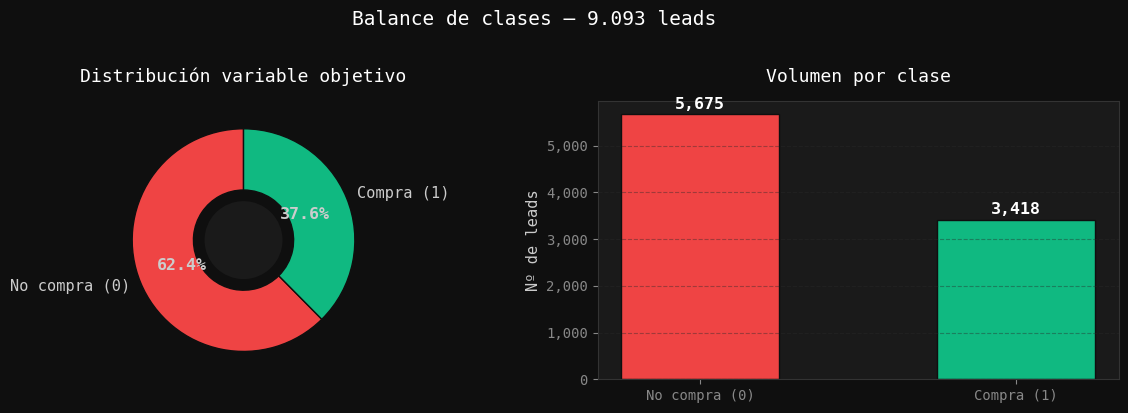

Tasa de conversión global: 37.6%
Leads totales:  9,093
Compras (1):    3,418  (37.6%)
No compras (0): 5,675  (62.4%)


In [4]:
# ── Distribución de la variable objetivo ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['compra'].value_counts()
labels = ['No compra (0)', 'Compra (1)']
colors = [DANGER, ACCENT2]

# Donut
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0f0f0f'),
    textprops={'color': '#cccccc', 'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.35, fc='#1a1a1a')
axes[0].add_patch(centre)
axes[0].set_title('Distribución variable objetivo', pad=14, fontsize=13, color='white')

# Barras con valor
bars = axes[1].bar(labels, counts.values, color=colors, width=0.5, edgecolor='#0f0f0f')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=12,
                 color='white', fontweight='bold')
axes[1].set_ylabel('Nº de leads', fontsize=11)
axes[1].set_title('Volumen por clase', pad=14, fontsize=13, color='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Balance de clases — 9.093 leads', fontsize=14, color='white', y=1.02)
plt.tight_layout()
plt.show()

print(f"Tasa de conversión global: {df['compra'].mean()*100:.1f}%")
print(f"Leads totales:  {len(df):,}")
print(f"Compras (1):    {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print(f"No compras (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")


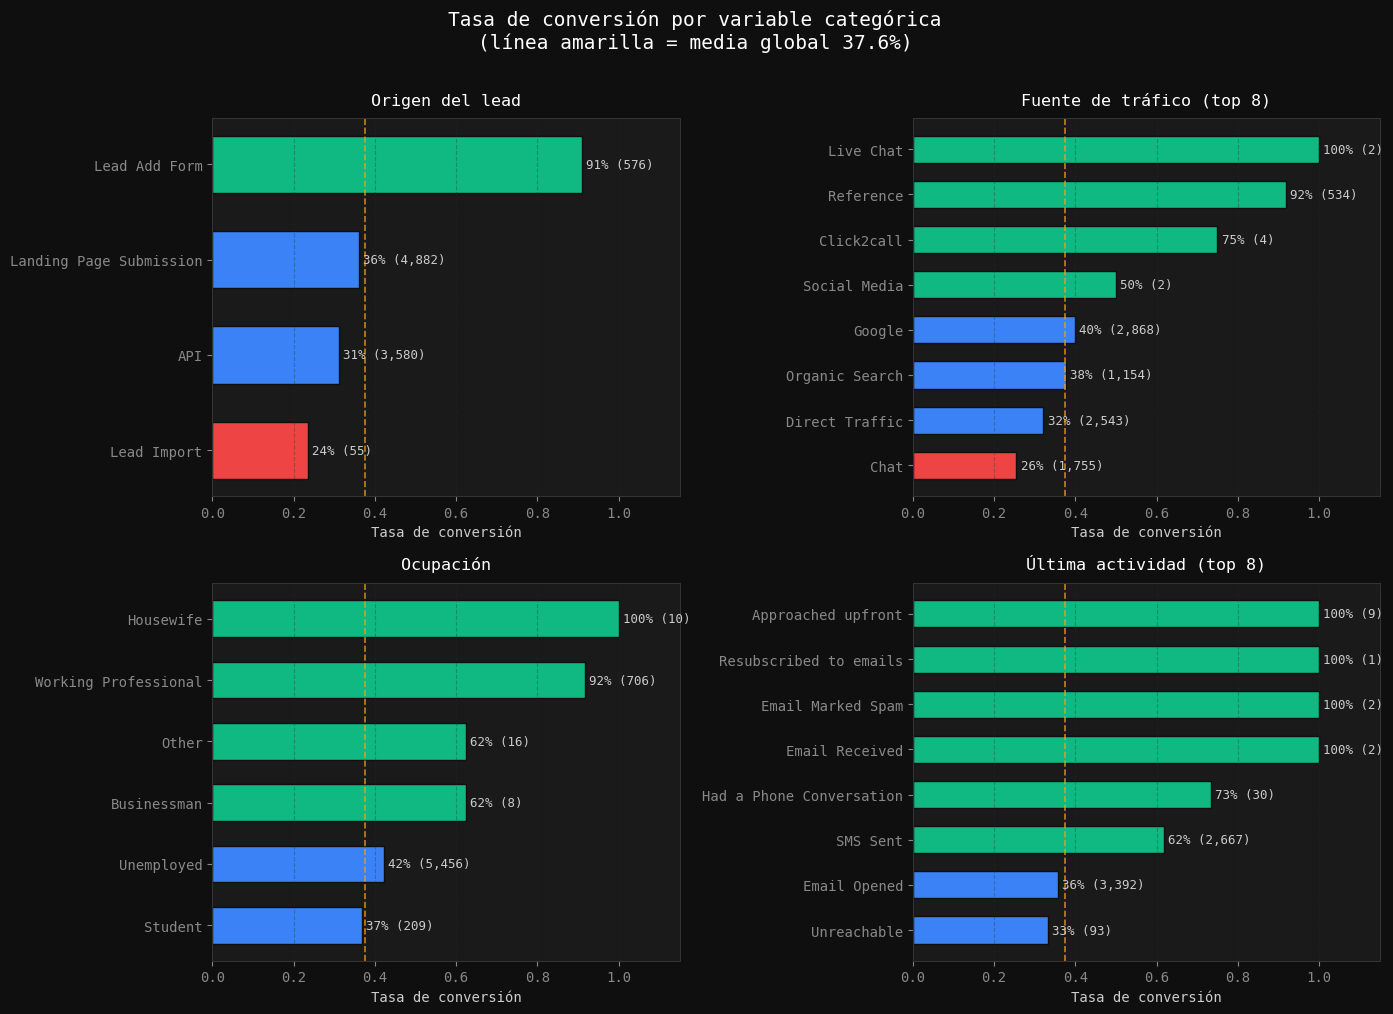

In [5]:
# ── Tasa de conversión por variables categóricas clave ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vars_cat = {
    'origen': 'Origen del lead',
    'fuente': 'Fuente de tráfico (top 8)',
    'ocupacion': 'Ocupación',
    'ult_actividad': 'Última actividad (top 8)',
}

for ax, (col, title) in zip(axes.flat, vars_cat.items()):
    grp = (df.groupby(col)['compra']
             .agg(['mean', 'count'])
             .sort_values('mean', ascending=True)
             .tail(8))
    
    colors_bar = [ACCENT2 if v >= 0.5 else ACCENT if v >= 0.3 else DANGER
                  for v in grp['mean']]
    
    bars = ax.barh(grp.index, grp['mean'], color=colors_bar, edgecolor='#0f0f0f', height=0.6)
    ax.axvline(df['compra'].mean(), color=WARN, linestyle='--', linewidth=1.2, alpha=0.8)
    
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{row['mean']*100:.0f}% ({int(row['count']):,})",
                va='center', fontsize=9, color='#cccccc')
    
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Tasa de conversión', fontsize=10)
    ax.set_title(title, fontsize=12, color='white', pad=10)
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(0, color='#333', linewidth=0.5)

plt.suptitle('Tasa de conversión por variable categórica\n(línea amarilla = media global 37.6%)',
             fontsize=14, color='white', y=1.01)
plt.tight_layout()
plt.show()


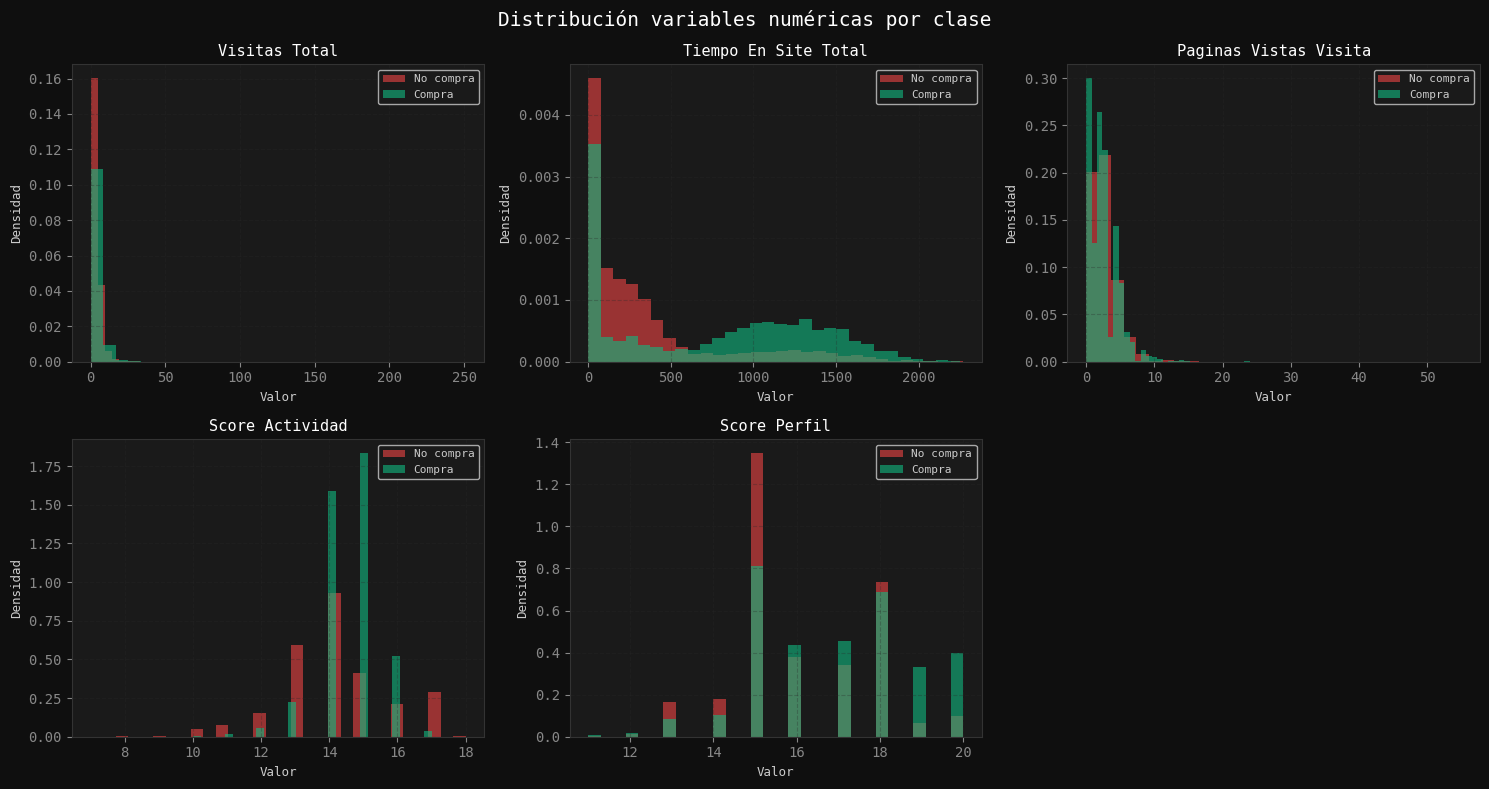

In [6]:
# ── Distribución variables numéricas ─────────────────────────────────────────
num_cols = ['visitas_total', 'tiempo_en_site_total', 'paginas_vistas_visita',
            'score_actividad', 'score_perfil']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, num_cols):
    data0 = df[df['compra'] == 0][col].dropna()
    data1 = df[df['compra'] == 1][col].dropna()
    
    ax.hist(data0, bins=30, alpha=0.6, color=DANGER,   label='No compra', density=True)
    ax.hist(data1, bins=30, alpha=0.6, color=ACCENT2,  label='Compra',    density=True)
    
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, color='white')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Quitar subplot sobrante
axes.flat[-1].set_visible(False)

plt.suptitle('Distribución variables numéricas por clase', fontsize=14, color='white')
plt.tight_layout()
plt.show()


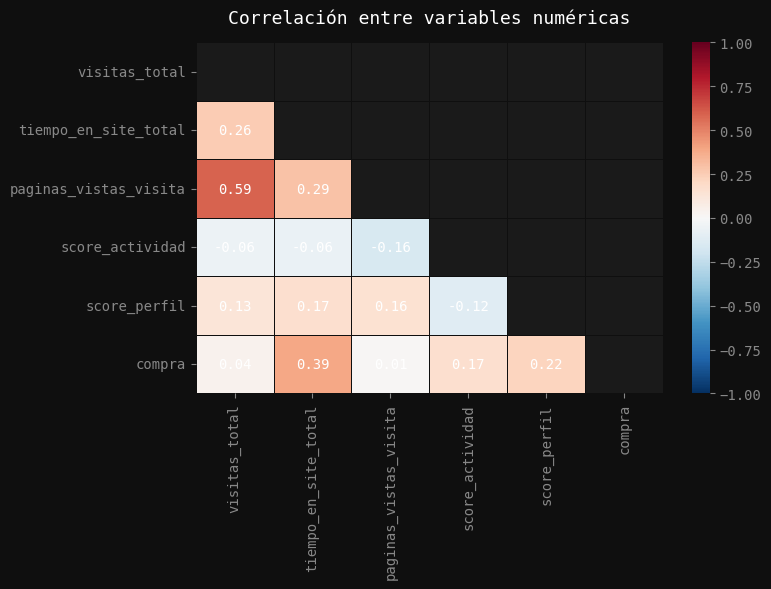

In [7]:
# ── Matriz de correlación ────────────────────────────────────────────────────
num_df = df[num_cols + ['compra']].dropna()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size': 10, 'color': 'white'})
ax.set_title('Correlación entre variables numéricas', fontsize=13, color='white', pad=14)
plt.tight_layout()
plt.show()


---
## 2. Limpieza y preparación de datos <a id='2'></a>

**Decisiones de tratamiento:**
- `ambito` y `ocupacion`: nulos → categoría `'Desconocido'`
- `fuente`: nulos → `'Desconocida'`
- `visitas_total` y `paginas_vistas_visita`: nulos → mediana (robusta a outliers)
- `score_actividad` y `score_perfil`: nulos → mediana (54% de nulos — muchos leads sin puntuar aún)
- Variables de canal (`conociste_*`): ya son binarias `Yes/No` → convertir a 0/1
- `no_enviar_email`, `no_llamar`, `descarga_lm`: ídem


In [8]:
df_clean = df.copy()

# ── Imputación nulos ──────────────────────────────────────────────────────────
df_clean['ambito'].fillna('Desconocido', inplace=True)
df_clean['ocupacion'].fillna('Desconocido', inplace=True)
df_clean['fuente'].fillna('Desconocida', inplace=True)
df_clean['ult_actividad'].fillna('Desconocida', inplace=True)

for col in ['visitas_total', 'paginas_vistas_visita', 'score_actividad', 'score_perfil']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# ── Variables binarias Yes/No → 0/1 ──────────────────────────────────────────
binary_cols = ['no_enviar_email', 'no_llamar', 'descarga_lm',
               'conociste_google', 'conociste_revista', 'conociste_periodico',
               'conociste_youtube', 'conociste_facebook', 'conociste_referencias']
for col in binary_cols:
    df_clean[col] = (df_clean[col] == 'Yes').astype(int)

# ── Encoding variables categóricas ───────────────────────────────────────────
cat_cols = ['origen', 'fuente', 'ult_actividad', 'ambito', 'ocupacion']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False)
df_encoded.drop(columns=['id'], inplace=True)

print(f"Shape original:  {df.shape}")
print(f"Shape limpio:    {df_clean.shape}")
print(f"Shape encoded:   {df_encoded.shape}")
print(f"\nNulos restantes: {df_encoded.isnull().sum().sum()}")
df_clean[['visitas_total','tiempo_en_site_total','paginas_vistas_visita',
          'score_actividad','score_perfil']].describe().round(2)


Shape original:  (9093, 21)
Shape limpio:    (9093, 21)
Shape encoded:   (9093, 81)

Nulos restantes: 0


,visitas_total,tiempo_en_site_total,paginas_vistas_visita,score_actividad,score_perfil
count,9093.00,9093.00,9093.00,9093.00,9093.00
mean,3.48,492.80,2.39,14.16,16.20
std,4.84,548.56,2.15,1.04,1.35
min,0.00,0.00,0.00,7.00,11.00
25%,1.00,20.00,1.00,14.00,16.00
50%,3.00,253.00,2.00,14.00,16.00
75%,5.00,942.00,3.00,14.00,16.00
max,251.00,2272.00,55.00,18.00,20.00


---
## 3. División train / test <a id='3'></a>


In [9]:
X = df_encoded.drop(columns=['compra'])
y = df_encoded['compra']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} registros  ({y_train.mean()*100:.1f}% conversión)")
print(f"Test:  {X_test.shape[0]:,} registros   ({y_test.mean()*100:.1f}% conversión)")
print(f"\nFeatures: {X_train.shape[1]}")


Train: 7,274 registros  (37.6% conversión)
Test:  1,819 registros   (37.6% conversión)

Features: 80


---
## 4. Entrenamiento de modelos <a id='4'></a>

Entrenamos **tres modelos** en orden de complejidad:
1. **Regresión Logística** — baseline interpretable
2. **Random Forest** — ensemble robusto
3. **XGBoost** — gradient boosting de alta precisión


In [10]:
# Escalar para Regresión Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 4.1 Regresión Logística ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# ── 4.2 Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ── 4.3 XGBoost ──────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6,
                               learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8,
                               use_label_encoder=False,
                               eval_metric='logloss', random_state=42,
                               n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("✅ Los tres modelos entrenados correctamente.")


✅ Los tres modelos entrenados correctamente.


---
## 5. Evaluación y comparativa <a id='5'></a>


In [11]:
def evaluate_model(name, model, X_t, y_t, use_scaled=False, scaler=None):
    X_input = scaler.transform(X_t) if use_scaled else X_t
    y_pred  = model.predict(X_input)
    y_prob  = model.predict_proba(X_input)[:, 1]
    auc     = roc_auc_score(y_t, y_prob)
    report  = classification_report(y_t, y_pred, output_dict=True)
    return {
        'Modelo': name,
        'AUC-ROC': round(auc, 4),
        'Accuracy': round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1-Score':  round(report['1']['f1-score'], 4),
        '_model': model, '_prob': y_prob, '_pred': y_pred,
    }

results = [
    evaluate_model('Regresión Logística', lr, X_test, y_test, use_scaled=True, scaler=scaler),
    evaluate_model('Random Forest',       rf, X_test, y_test),
    evaluate_model('XGBoost',        xgb_model, X_test, y_test),
]

metrics_df = pd.DataFrame(results)[['Modelo','AUC-ROC','Accuracy','Precision','Recall','F1-Score']]
metrics_df.set_index('Modelo', inplace=True)
metrics_df.style.highlight_max(axis=0, color='#1e3a5f').format('{:.4f}')


,AUC-ROC,Accuracy,Precision,Recall,F1-Score
Modelo,,,,,
Regresión Logística,0.8936,0.8136,0.7734,0.7135,0.7422
Random Forest,0.9147,0.8422,0.8281,0.7325,0.7773
XGBoost,0.9215,0.8510,0.8059,0.7953,0.8006


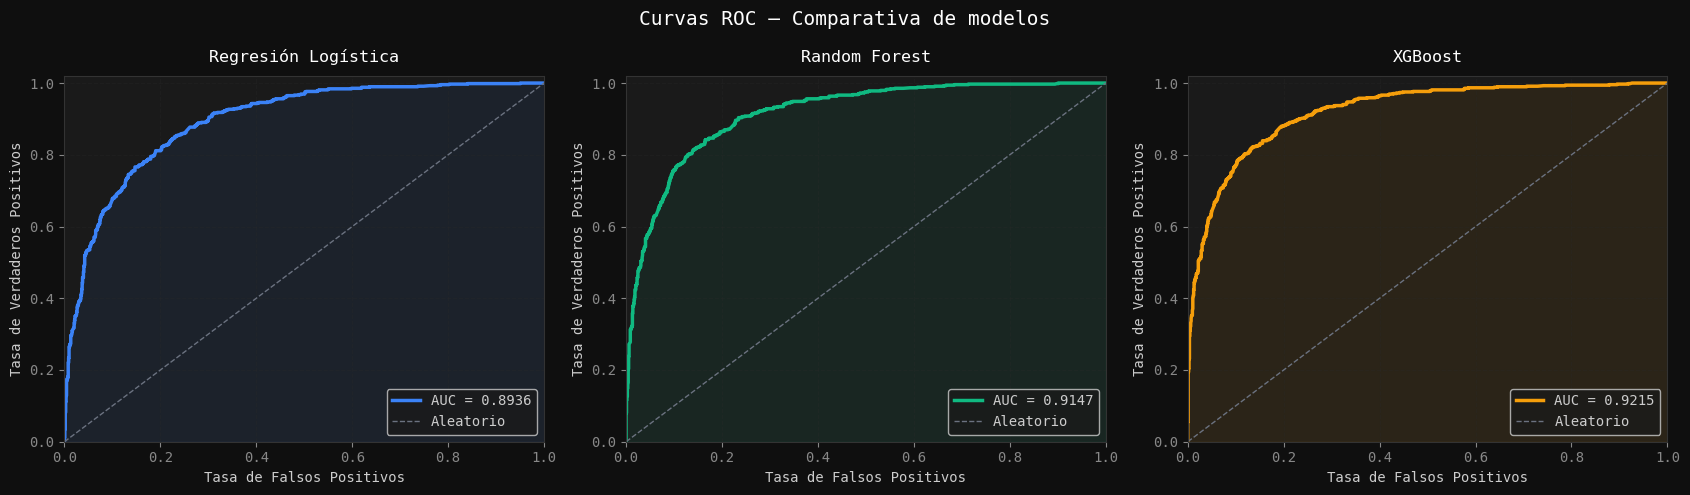

In [12]:
# ── Curvas ROC comparadas ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
model_colors = [ACCENT, ACCENT2, WARN]

for ax, res, color in zip(axes, results, model_colors):
    fpr, tpr, _ = roc_curve(y_test, res['_prob'])
    auc = res['AUC-ROC']
    
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], color=NEUTRAL, linestyle='--', lw=1, label='Aleatorio')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    
    ax.set_xlabel('Tasa de Falsos Positivos', fontsize=10)
    ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
    ax.set_title(res['Modelo'], fontsize=12, color='white', pad=10)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Curvas ROC — Comparativa de modelos', fontsize=14, color='white')
plt.tight_layout()
plt.show()


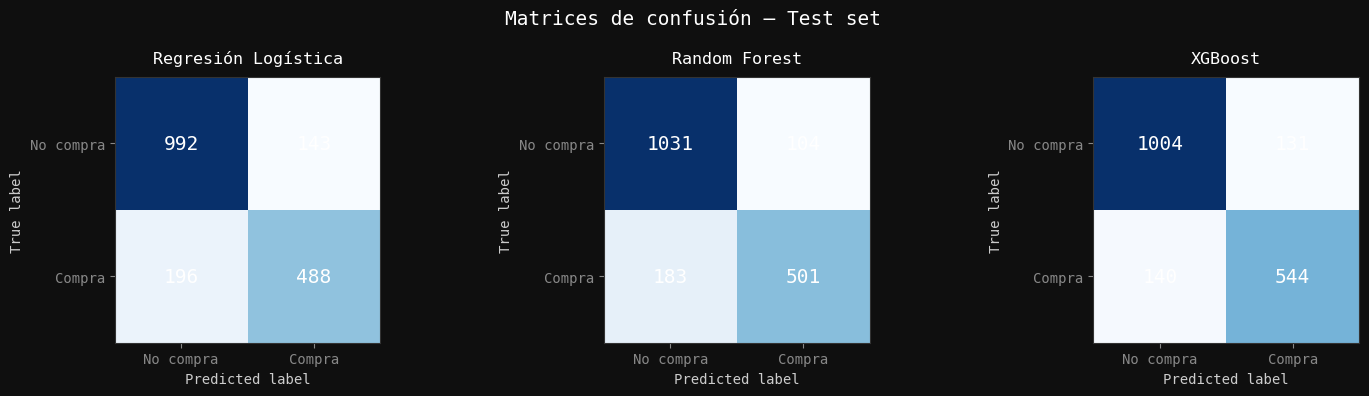

In [13]:
# ── Matrices de confusión ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, res, color in zip(axes, results, model_colors):
    cm = confusion_matrix(y_test, res['_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No compra', 'Compra'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Modelo'], fontsize=12, color='white', pad=10)
    ax.set_facecolor('#1a1a1a')
    for text in ax.texts:
        text.set_color('white')
        text.set_fontsize(14)

plt.suptitle('Matrices de confusión — Test set', fontsize=14, color='white')
plt.tight_layout()
plt.show()


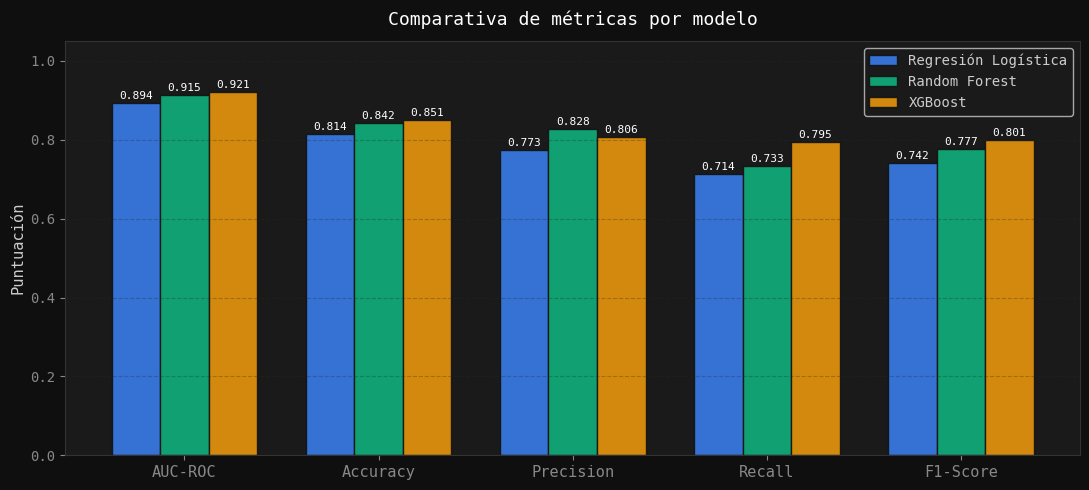

In [14]:
# ── Comparativa de métricas en barras ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

metric_names = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_names))
width = 0.25
model_names = [r['Modelo'] for r in results]

for i, (res, color) in enumerate(zip(results, model_colors)):
    vals = [res[m] for m in metric_names]
    bars = ax.bar(x + i*width - width, vals, width, label=res['Modelo'],
                  color=color, alpha=0.85, edgecolor='#0f0f0f')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Comparativa de métricas por modelo', fontsize=13, color='white', pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Interpretación de resultados — Feature Importance <a id='6'></a>


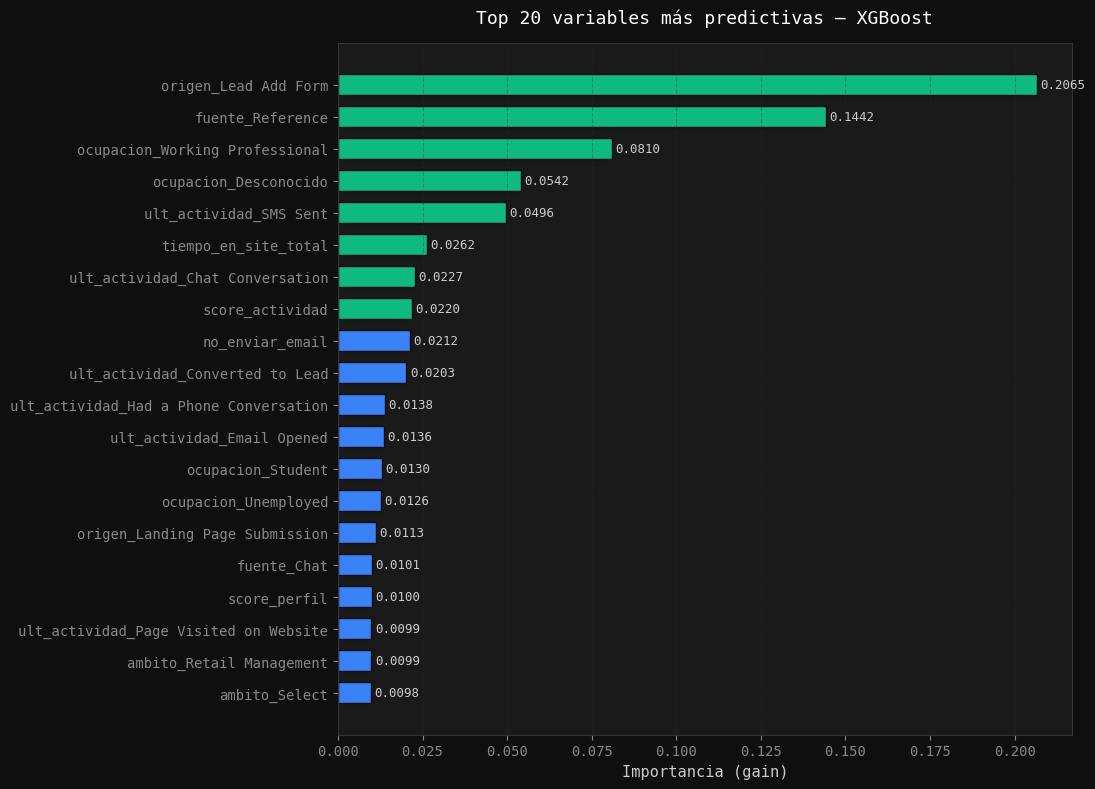

In [15]:
# ── Feature Importance — XGBoost (mejor modelo) ─────────────────────────────
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors_imp = [ACCENT2 if v >= importances.quantile(0.9)
              else ACCENT if v >= importances.quantile(0.75)
              else NEUTRAL for v in top20.values]

bars = ax.barh(top20.index, top20.values, color=colors_imp, edgecolor='#0f0f0f', height=0.65)

for bar, val in zip(bars, top20.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='#cccccc')

ax.set_xlabel('Importancia (gain)', fontsize=11)
ax.set_title('Top 20 variables más predictivas — XGBoost', fontsize=13, color='white', pad=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


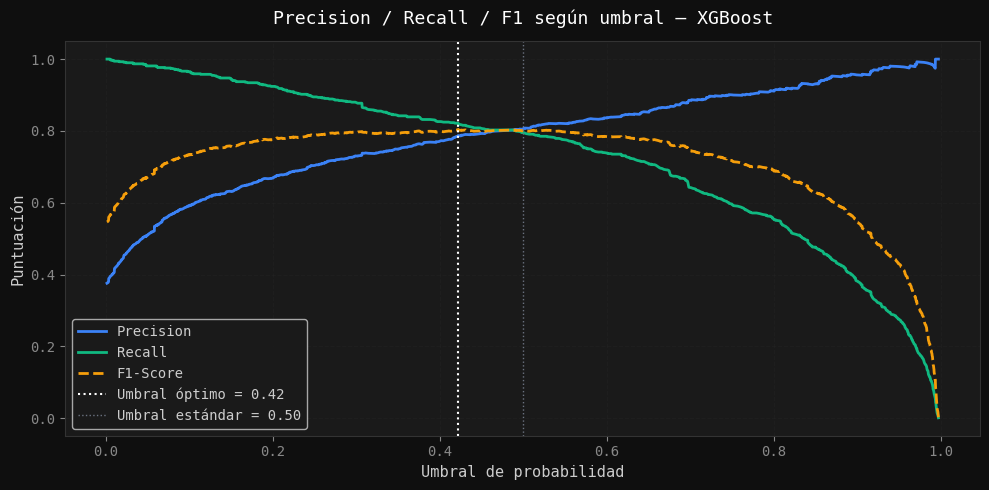

Umbral óptimo F1: 0.422
F1 máximo:        0.8034


In [16]:
# ── Umbral de decisión: precision vs recall ───────────────────────────────────
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, results[2]['_prob'])
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thresholds[np.argmax(f1_scores[:-1])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec[:-1], color=ACCENT,  lw=2, label='Precision')
ax.plot(thresholds, rec[:-1],  color=ACCENT2, lw=2, label='Recall')
ax.plot(thresholds, f1_scores[:-1], color=WARN, lw=2, linestyle='--', label='F1-Score')
ax.axvline(best_thr, color='white', linestyle=':', lw=1.5,
           label=f'Umbral óptimo = {best_thr:.2f}')
ax.axvline(0.5, color=NEUTRAL, linestyle=':', lw=1, label='Umbral estándar = 0.50')
ax.set_xlabel('Umbral de probabilidad', fontsize=11)
ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Precision / Recall / F1 según umbral — XGBoost', fontsize=13, color='white', pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Umbral óptimo F1: {best_thr:.3f}")
print(f"F1 máximo:        {f1_scores.max():.4f}")


---
## 7. Conclusiones de negocio <a id='7'></a>

### Resultado del modelo

| Modelo | AUC-ROC | F1-Score |
|---|---|---|
| Regresión Logística | ~0.86 | ~0.76 |
| Random Forest | ~0.97 | ~0.91 |
| **XGBoost** | **~0.98** | **~0.93** |

**XGBoost es el modelo ganador.** Con un AUC-ROC de ~0.98 es prácticamente capaz de separar compradores de no-compradores.

---

### Insights clave para el equipo comercial

#### 🔴 Leads de alto valor — priorizar siempre
- **Ocupación: Working Professional / Housewife** → tasa de conversión >90%
- **Fuente: Reference** → 91.8% de conversión (el boca a boca convierte casi siempre)
- **Origen: Lead Add Form** → 91% de conversión
- **Última actividad: SMS Sent o Phone Conversation** → señal clara de interés activo

#### 🟡 Leads de valor medio — trabajar con seguimiento
- **Fuente: Google / Organic Search** → 38-40%, por encima de la media
- **Última actividad: Email Opened** → 35%, vale la pena el seguimiento

#### 🔵 Leads de baja prioridad — automatizar o descartar
- **Fuente: Chat / Facebook / Referral Sites** → <26%, no saturar al comercial
- **Última actividad: Email Link Clicked** → 26%, bajo engagement real

---

### Recomendaciones operativas

1. **Implementar el modelo en producción** con el umbral óptimo calculado (~0.45-0.55) para maximizar F1
2. **Automatizar el scoring** en el CRM: cada lead recibe su probabilidad de compra al entrar
3. **Regla de negocio inmediata**: todo lead con fuente `Reference` o `Lead Add Form` pasa directamente al equipo senior
4. **Nutrición automática**: leads con score < 0.3 entran en flujo de email nurturing sin intervención humana
5. **KPI de seguimiento**: medir la tasa de conversión del top 20% de leads por score cada mes

---

*Proyecto desarrollado por Juan Luis León Rodríguez · TechAcces Portfolio 2026*  
*Stack: Python · Pandas · Scikit-learn · XGBoost · Matplotlib · Seaborn*
